In [20]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

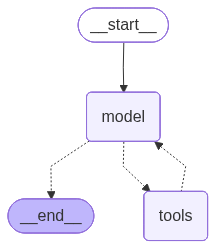

In [21]:
from langchain.agents import create_agent

def get_weather(city : str) -> str:
    """Get the weather for a city."""
    return f"The weather is {city} is sunny"

agent = create_agent(
    model = "gpt-5",
    tools = [get_weather],
    system_prompt = "You are a helpful assistant"
)
agent

In [ ]:
response = agent.invoke({
    "messages" : [
        {
            "role" : "user",
            "content" : "What is the weather like in New York?"
        }
    ]
})

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [18]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature= 0,
    max_tokens=100       # 👈 limits output tokens
)

agent = create_agent(
    model = llm,
    tools = [get_weather],
    system_prompt = "You are a helpful assistant"
)

In [19]:
response = agent.invoke({
    "messages" : [{
        "role" : "user",
        "content" : "What is weather is New York?"
    }]
})
response["messages"]

KeyboardInterrupt: 

In [11]:
response["messages"][-1].content

"I'm sorry, I can't verify the weather in New York City."